In [1]:
import sys
sys.path.insert(0, '../py')

import numpy as np
import matplotlib.pyplot as plt
from spectra_loader import SpectraDataset

In [2]:
ds = SpectraDataset('../spectra/', zerr_catalog='../metadata/desi-galaxy-cat-zerr.fits', n_spectra=8, desi_target_mask=1, zmin=0.4,zmax=0.7)
wave = ds.wave.numpy()
print(f'Loaded {len(ds)} spectra, wavelength range {wave[0]:.0f}\u2013{wave[-1]:.0f} \u00c5')

Loaded 8 spectra, wavelength range 3600–9824 Å


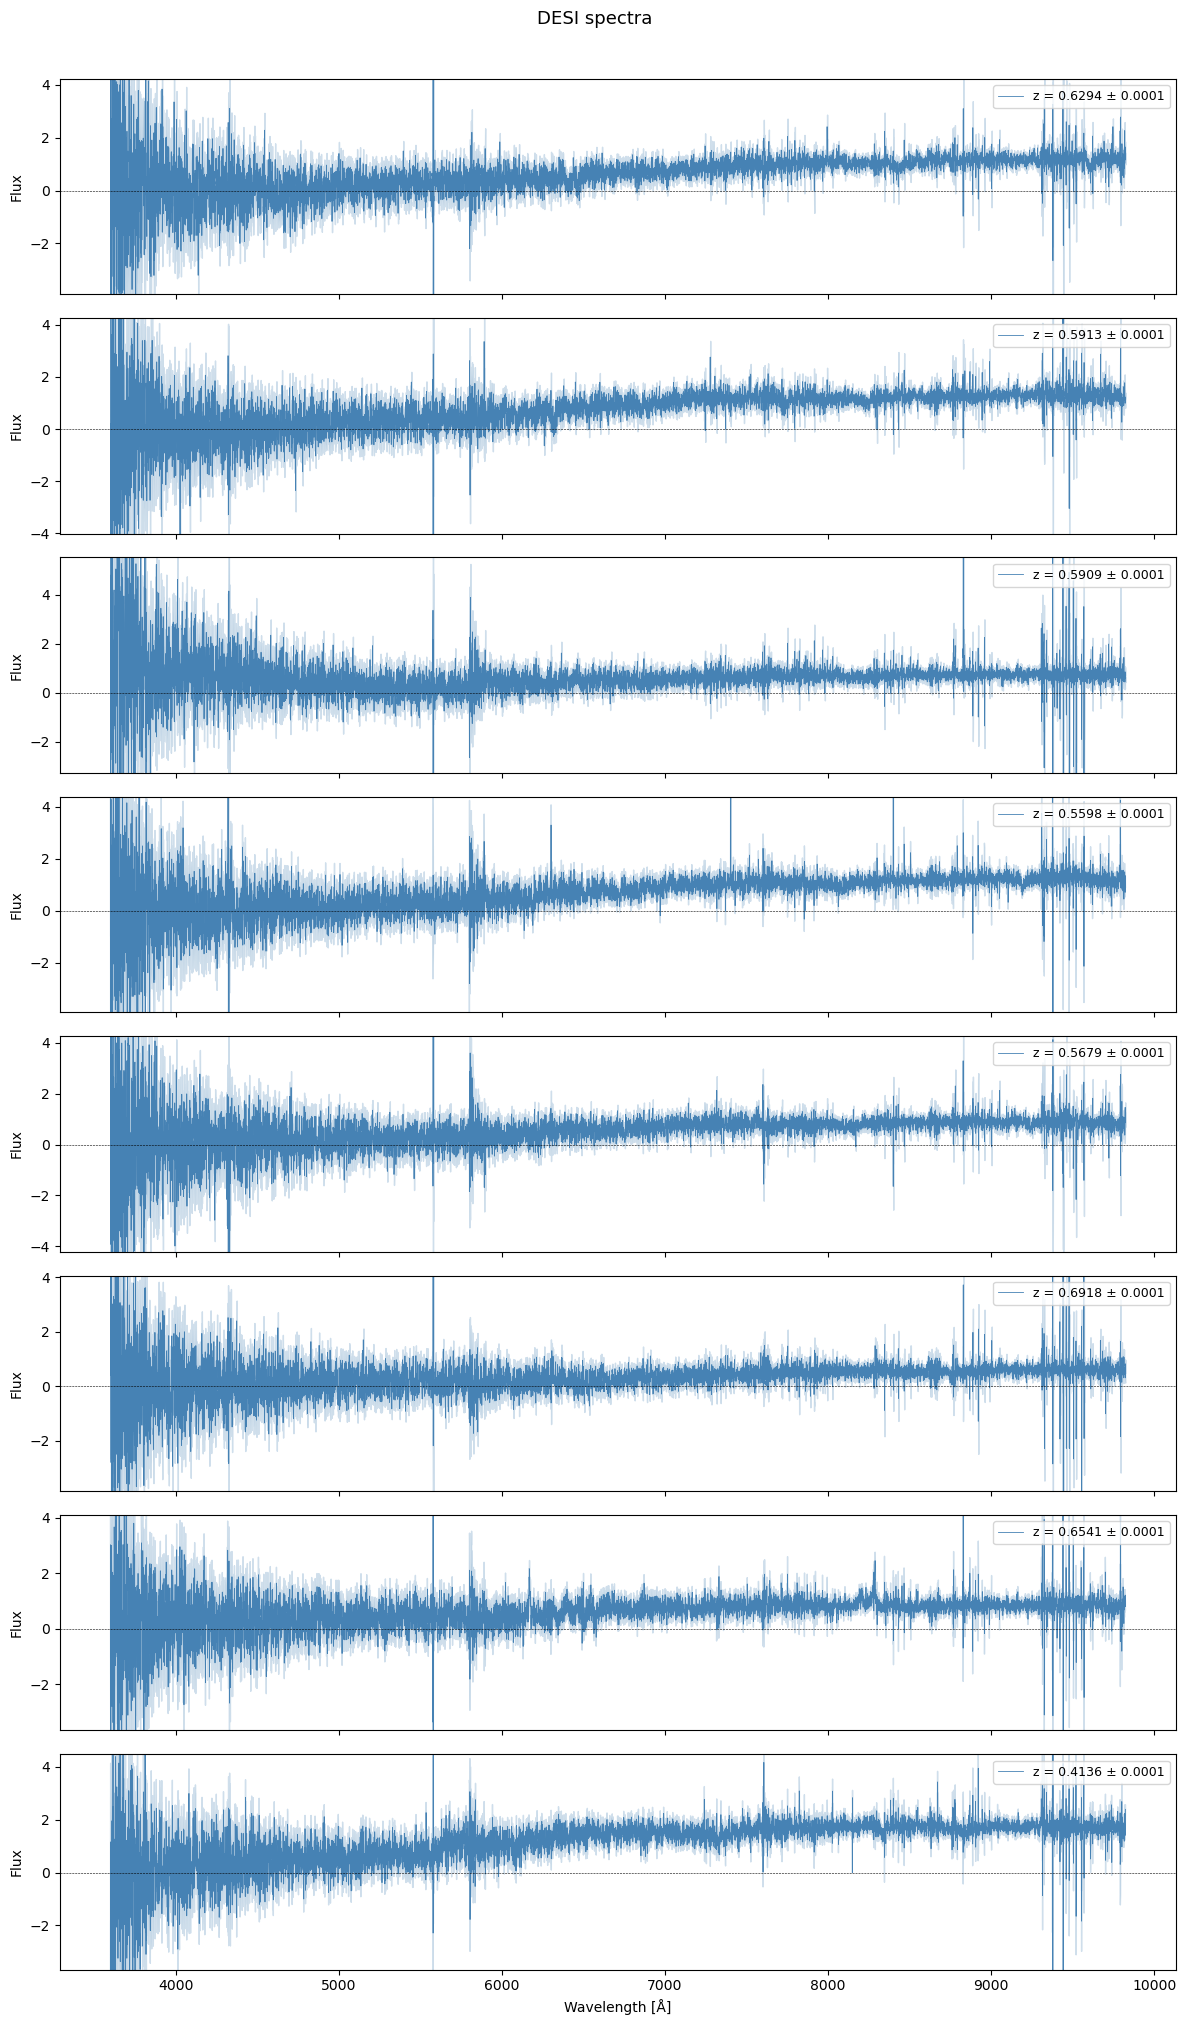

: 

In [ ]:
fig, axes = plt.subplots(len(ds), 1, figsize=(12, 2.5 * len(ds)), sharex=True)

for i, ax in enumerate(axes):
    item = ds[i]
    flux = item['flux'].numpy()
    ivar = item['ivar'].numpy()
    z    = item['z'].item()
    zerr = item['zerr'].item()

    # 1-sigma uncertainty from inverse variance (zero ivar -> masked out)
    safe_ivar = np.where(ivar > 0, ivar, np.nan)
    sigma = 1.0 / np.sqrt(safe_ivar)

    ax.plot(wave, flux, lw=0.6, color='steelblue', label=f'z = {z:.4f} \u00b1 {zerr:.4f}')
    ax.fill_between(wave, flux - sigma, flux + sigma, alpha=0.25, color='steelblue')
    ax.axhline(0, color='k', lw=0.4, ls='--')
    ax.set_ylabel('Flux')
    ax.legend(loc='upper right', fontsize=9)
    ax.set_ylim(np.nanpercentile(flux, 1) - 2, np.nanpercentile(flux, 99) + 2)

axes[-1].set_xlabel('Wavelength [\u00c5]')
fig.suptitle('DESI spectra', y=1.01, fontsize=13)
fig.tight_layout()
plt.show()

In [8]:
wave.max()

np.float32(9824.0)